In [1]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

In [2]:
# choose the data to analyze

mutants = ['wt', 'N214A', 'Q256A', 'S284A']
mutant_colors  = ['k', 'b', 'g', 'orange']

ks_s = [
        KineticsSeries('./wt/wt.yaml', corrections='./config.yaml', prefix='./wt'),
        KineticsSeries('./N214A/n214a.yaml', corrections='./config.yaml', prefix='./N214A'),
        KineticsSeries('./Q256A/q256a.yaml', corrections='./config.yaml', prefix='./Q256A'),
        KineticsSeries('./S284A/s284a.yaml', corrections='./config.yaml', prefix='./S284A'),
       ]

#    ks = KineticsSeries('./wt_dmso/wt_dmso.yaml', corrections='./config.yaml', prefix='./wt_dmso')

normal_ps = [5.0, 10.0, 20.0, 40.0, 80.0, 160.0]
n214a_ps = [5.0, 10.0, 20.0, 40.0, 80.0, 160.0, 320.0, 640.0, 1280.0, 2560.0, 5120.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

Loading: 210401_2µM_MproWT.csv...
 ... excluded
Loading: 210401_buffer_200µM_MproWT.csv...
 ... excluded
Loading: 210413_02_002µM_MproWT.csv...
 ... excluded
Loading: 210413_buffer_2µM_MproWT.csv...
 ... excluded
Loading: 210420_20µM_MproWT.csv...
 ... excluded
Loading: 210420_10µM_MproWT.csv...
 ... excluded
Loading: 210420_5_and_2µM_MproWT.csv...
 ... excluded
Loading: 210430_20_10_5_and_2µM_MproWT.csv...
Loading: 210430_buffer_160_80_and_40µM_MproWT.csv...
 ... excluding E=160.00 / S=160.00
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210414_20_2_02_002µM_MproN214A.csv...
 ... excluded
Loading: 210421_20_and_10_µM_MproN214A.csv...
 ... excluded
Loading: 210421_5_and_2_µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A_2.csv...
 ... excluded
Loading: 210427_40_20_and_10µM_MproN214A.csv...
 ... excluding E=20.0

In [3]:
for ks in ks_s:
    ks.fit_v0(r2_threshold=0.0)

N214A
11 7


<IPython.core.display.Javascript object>


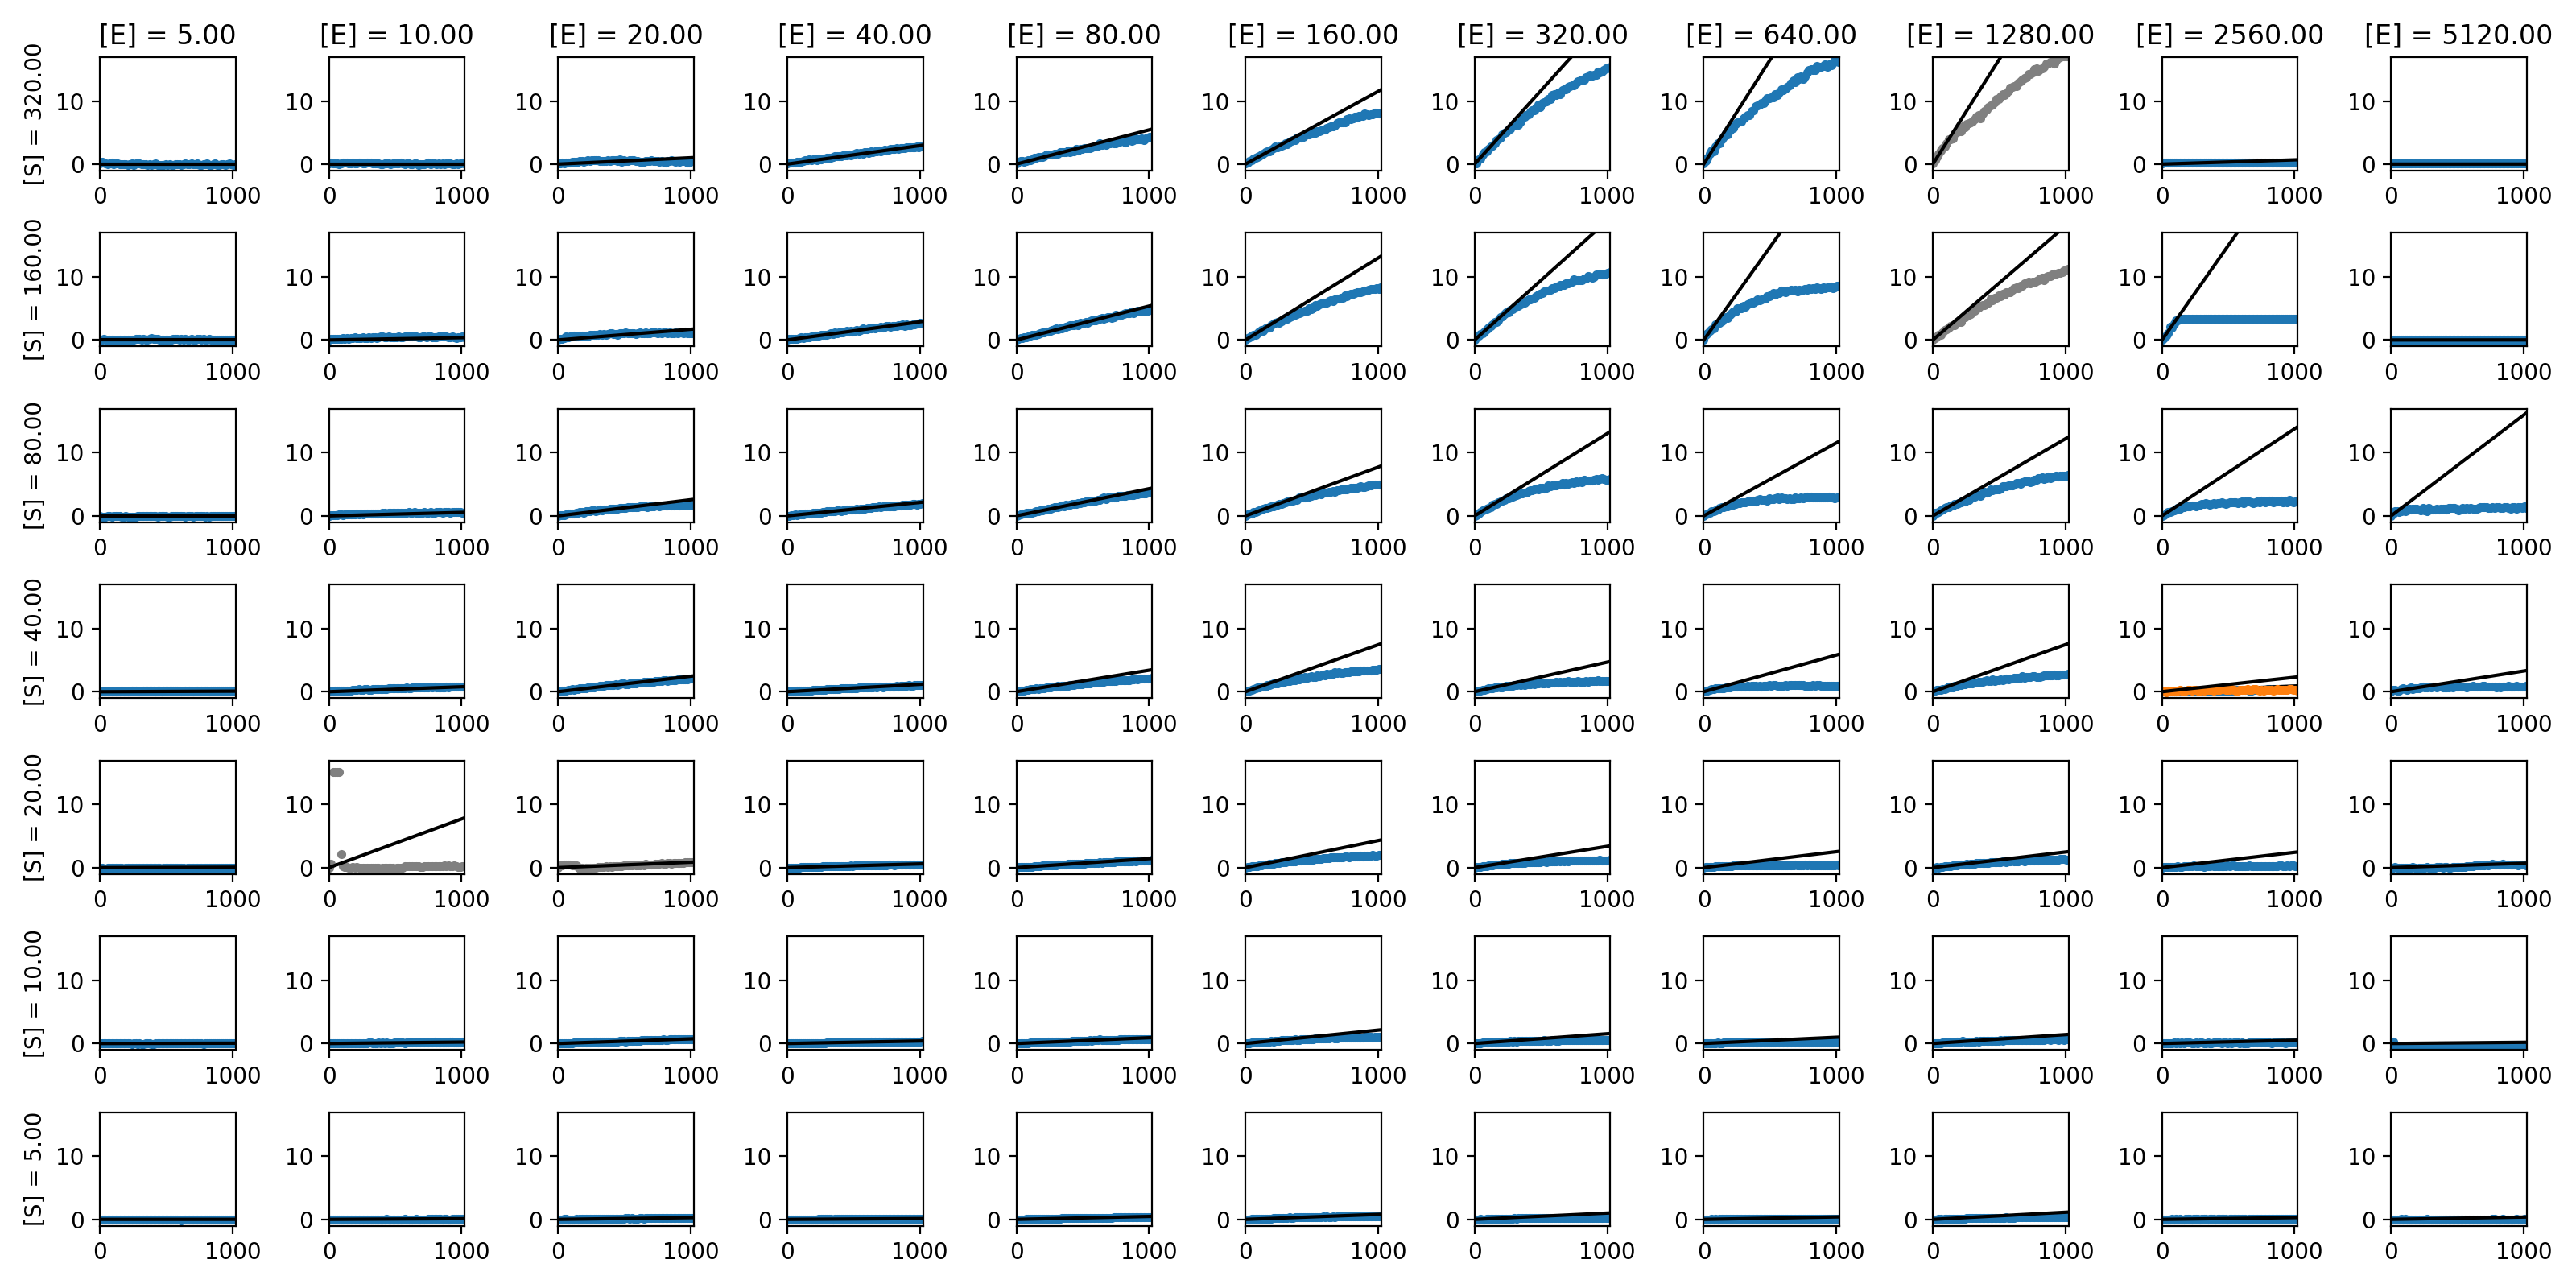

excluded: p=10.000000 / s=20.000000
excluded: p=20.000000 / s=20.000000
excluded: p=1280.000000 / s=320.000000
excluded: p=1280.000000 / s=160.000000


In [4]:
# choose one mutant and inspect

mutant_index = 1
mutant = mutants[mutant_index]
print(mutant)

if mutant_index == 1:
    ps = n214a_ps
else:
    ps = normal_ps
    
n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)


ks = ks_s[mutant_index]

fig, axes = plt.subplots(n_s, n_p, figsize=(16,8))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        v0_set = []
        
        for entry in ks.get(p, s):
            
            if i_s == 0:
                axes[i_s, i_p].set_title('[E] = %.2f' % p)
            if i_p == 0:
                axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)
                
            axes[i_s, i_p].set_xlim([0, 1024])
            axes[i_s, i_p].set_ylim([-1, 17])
            
            t = entry['dt'] * np.arange(len(entry['timeseries']))
            
            if entry['exclude']:
                axes[i_s, i_p].plot(t, entry['timeseries'], '.', color='gray')
                axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
                print('excluded: p=%f / s=%f' % (p, s))
                continue
            
            axes[i_s, i_p].plot(t, entry['timeseries'], '.')
            axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
            
plt.tight_layout()
plt.savefig('figures/%s_traces.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


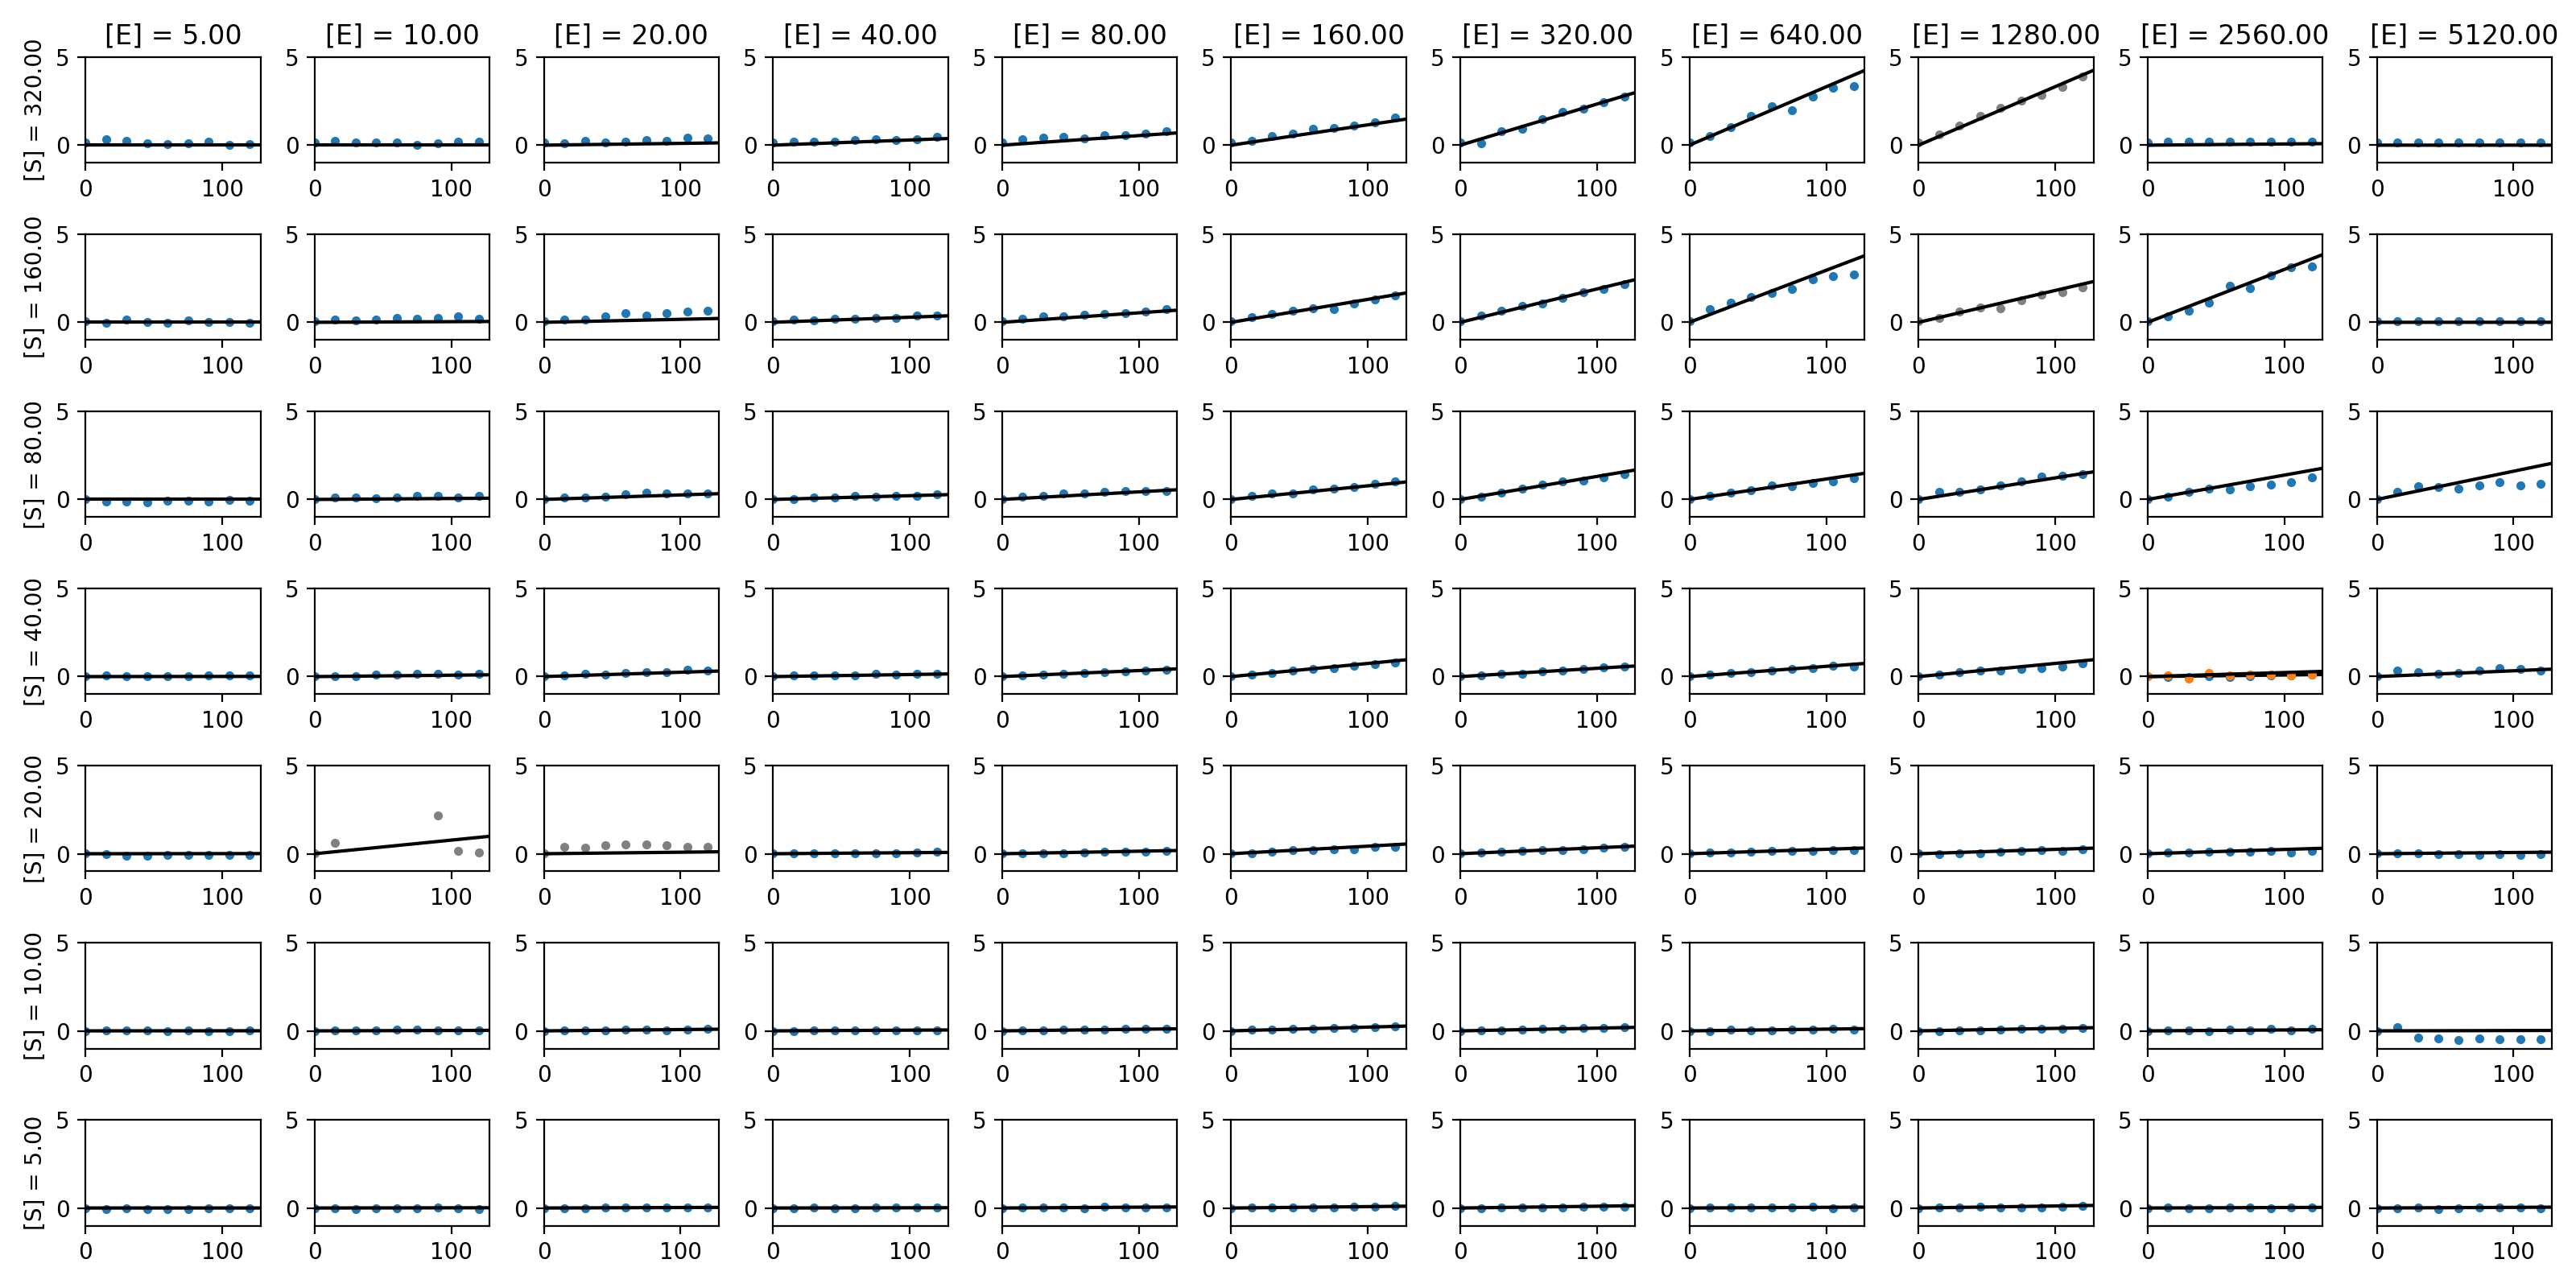

excluded: p=10.000000 / s=20.000000
excluded: p=20.000000 / s=20.000000
excluded: p=1280.000000 / s=320.000000
excluded: p=1280.000000 / s=160.000000


In [5]:
fig, axes = plt.subplots(n_s, n_p, figsize=(16,8))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        v0_set = []
        
        for entry in ks.get(p, s):
            
            if i_s == 0:
                axes[i_s, i_p].set_title('[E] = %.2f' % p)
            if i_p == 0:
                axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)
                
            axes[i_s, i_p].set_xlim([0, 128])
            axes[i_s, i_p].set_ylim([-1, 5])
            
            #print('v0, v0err / %.2e %.2e' % (entry['v0'], entry['stderr_v0']))
            
            t = entry['dt'] * np.arange(len(entry['timeseries']))
            
            if entry['exclude']:
                axes[i_s, i_p].plot(t, entry['timeseries'], '.', color='gray')
                axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
                print('excluded: p=%f / s=%f' % (p, s))
                continue
            
            axes[i_s, i_p].plot(t, entry['timeseries'], '.')
            axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
            
plt.tight_layout()
plt.savefig('figures/%s_traces_zoom.pdf' % mutant)
plt.show()

## Fit all mutants

In [6]:
# capture the k_cat, K_m for each mutant
# (mutants, protein_concentrations, conc/k_cat/k_cat_err/K_m/K_m_err)

kinetic_params = np.zeros([4, 11, 5])

<IPython.core.display.Javascript object>


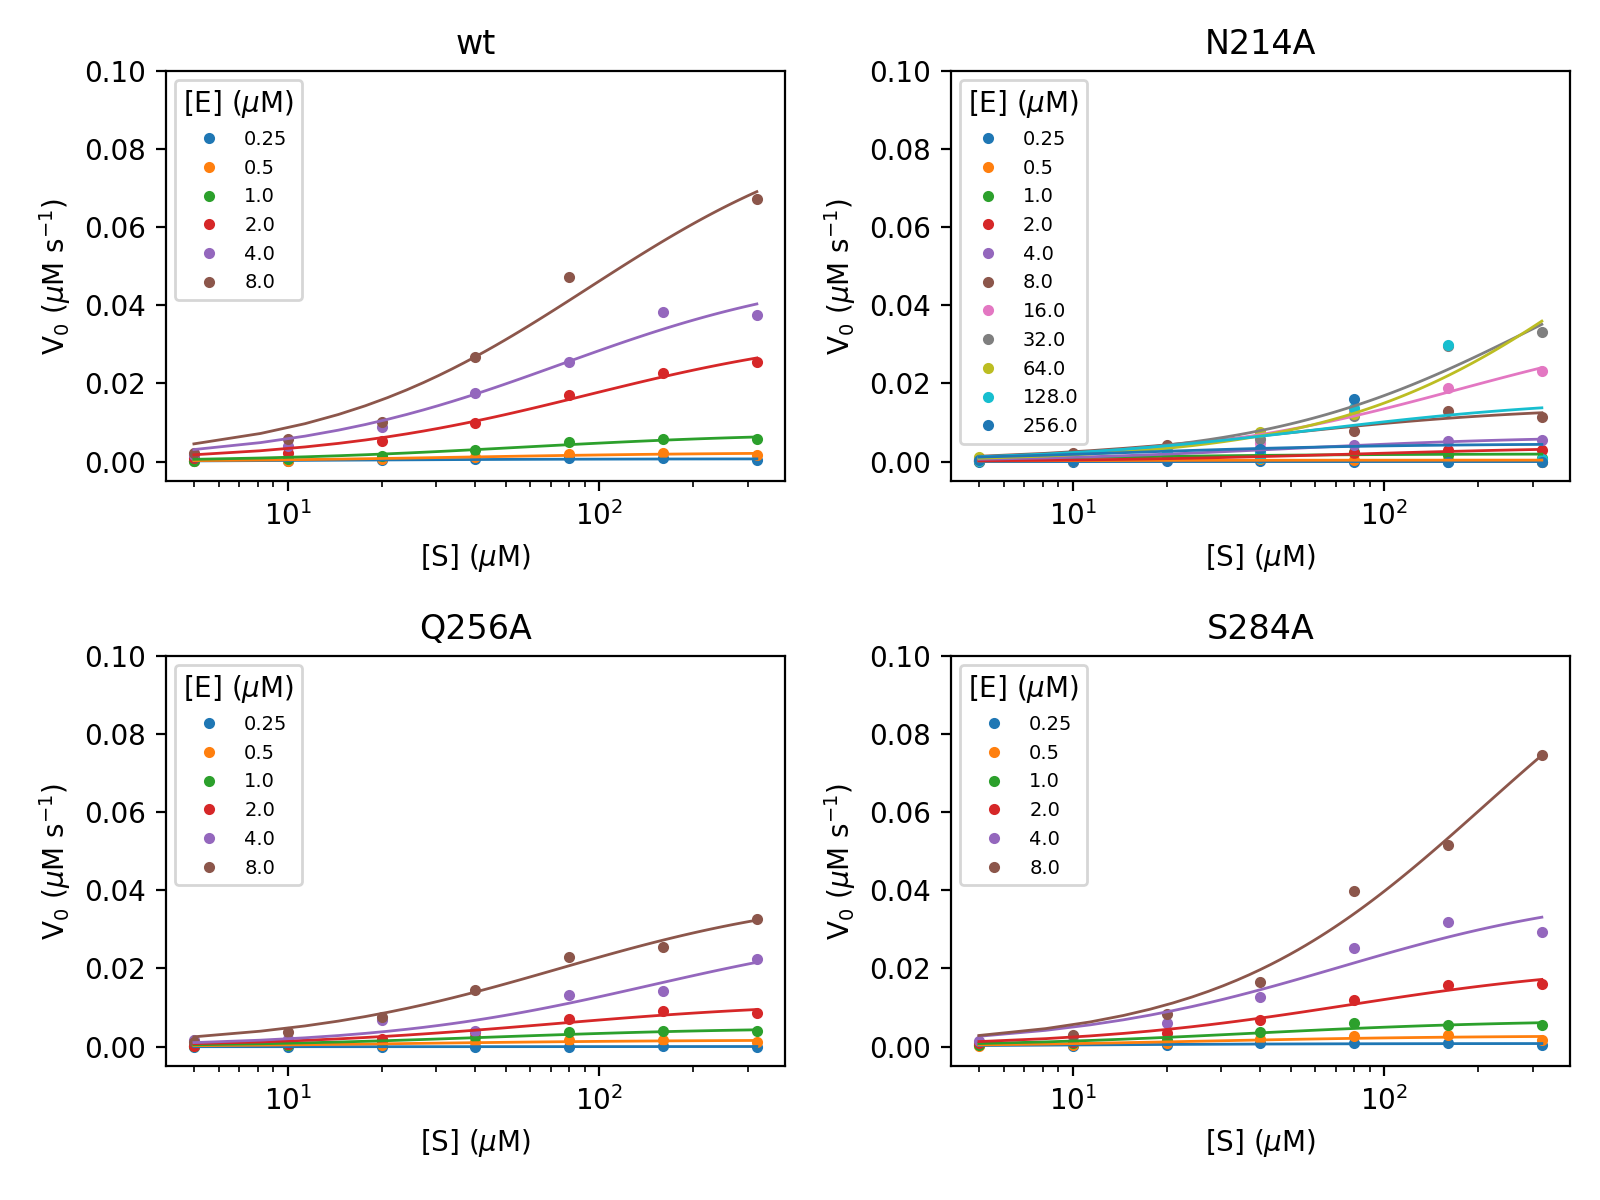


---wt---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.25	2.98e-03	7.73e-04	1.35e+01	1.46e+01
0.50	4.76e-03	8.85e-04	3.79e+01	2.25e+01
1.00	7.44e-03	8.88e-04	5.65e+01	1.93e+01
2.00	1.71e-02	1.08e-03	9.14e+01	1.43e+01
4.00	1.25e-02	1.17e-03	7.53e+01	1.86e+01
8.00	1.11e-02	1.23e-03	9.28e+01	2.44e+01

---N214A---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.25	1.13e-04	7.63e-05	4.38e-02	7.84e+00
0.50	8.15e-04	3.73e-04	4.42e+00	1.23e+01
1.00	1.99e-03	5.47e-04	9.45e+00	1.28e+01
2.00	1.98e-03	1.91e-04	8.18e+01	2.03e+01
4.00	1.66e-03	1.27e-04	4.86e+01	1.11e+01
8.00	1.79e-03	1.99e-04	4.67e+01	1.56e+01
16.00	2.32e-03	3.13e-04	1.74e+02	4.74e+01
32.00	2.14e-03	7.49e-04	3.05e+02	1.80e+02
64.00	1.53e-03	2.29e-03	5.54e+02	9.26e+02
128.00	1.28e-04	1.13e-04	6.07e+01	1.39e+02
256.00	1.81e-05	1.90e-05	1.46e+01	6.23e+01

---Q256A---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.25	4.19e-04	6.55e-04	3.91e+02	9.58e+02
0.50	3.47e-03	5.38e-04	2.74e+01	1.47e+01
1.00	4.93e-03	5.19e-04	4.

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))

for im, m in enumerate(mutants):
    
    if im == 1:
        ps = n214a_ps
    else:
        ps = normal_ps
    
    ks = ks_s[im]
    
    print('\n---' + m + '---\n')

    ax = axes[ im//2, im%2 ]
    ax.set_title(m)
    
    for p in ps:
        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
        ax.plot(s0s, v0s, '.')

    ax.legend( np.array(ps) / 20.0, title='[E] ($\mu$M)', fontsize=7, loc=2)

    # fit
    print('[E]\tk_cat\t\terr\t\tK_m\t\terr')
    print('---\t-----\t\t---\t\t---\t\t---')

    ax.set_prop_cycle(None)
    for i,p in enumerate(ps):

        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)

        (k_cat, K_m), perr = fit_mm(v0s, s0s, p / 20.0, v0errs=None)

        print('%.2f\t%.2e\t%.2e\t%.2e\t%.2e' % (p / 20.0, k_cat, perr[0], K_m, perr[1]))
        kinetic_params[im,i,:] = np.array([p, k_cat, perr[0], K_m, perr[1]])

        S = np.linspace(ss.min(), ss.max(), 100)
        V_fit = mm( p / 20.0, S, k_cat, K_m)
        ax.plot(S, V_fit, lw=1)
        ax.set_xscale('log')
    
    #ax.set_xscale('log')
    ax.set_ylim([-0.005, 0.1])
    ax.set_xlabel('[S] ($\mu$M)')
    ax.set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')
    
plt.tight_layout()
plt.savefig('figures/mm.pdf')
plt.show()

<IPython.core.display.Javascript object>


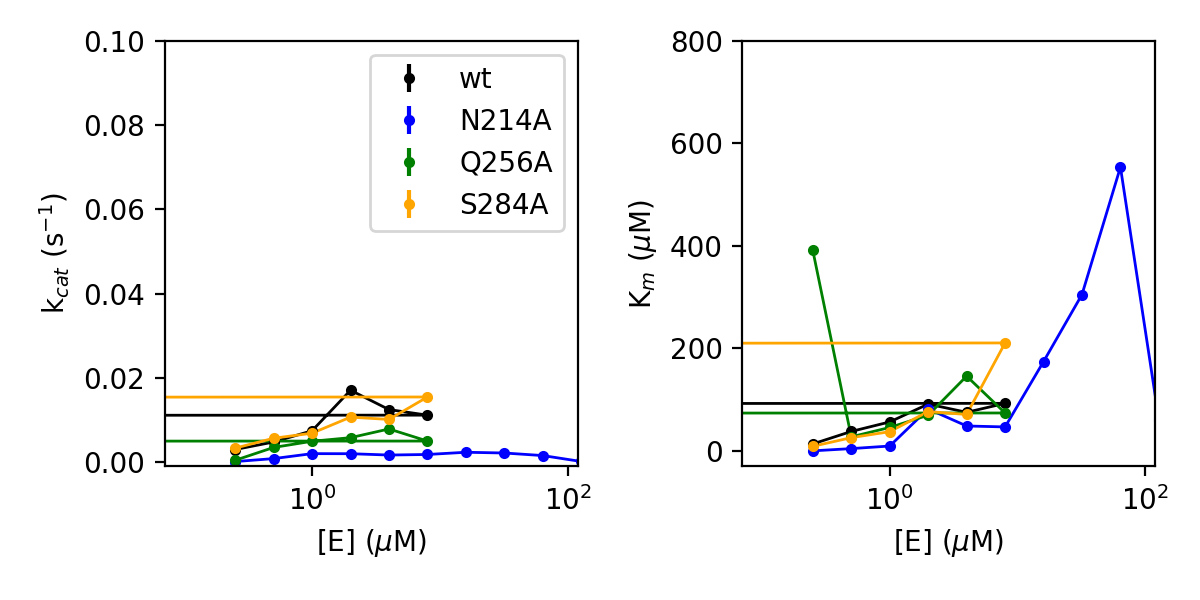

In [10]:
# by fiat, set Q256A E=0.1,0.25 values to zero (unmeasurable)
# -----

plt.figure(figsize=(6,3))

plt.subplot(121)
for im, m in enumerate(mutants):
    plt.errorbar(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,1], fmt='.',
                 yerr=0.0, #kinetic_params[im,:,2],
                 color=mutant_colors[im])
    plt.plot(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,1], 
             '-', color=mutant_colors[im], lw=1, label='_nolegend_')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('k$_{cat}$ (s$^{-1}$)')
plt.xscale('log')
plt.ylim([-0.001, 0.1])
plt.xlim([0.07, 120.0])
plt.legend(mutants)

plt.subplot(122)
for im, m in enumerate(mutants):
    plt.errorbar(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,3], fmt='.',
                 yerr=0.0, #kinetic_params[im,:,4],
                 color=mutant_colors[im])
    plt.plot(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,3], 
             '-', color=mutant_colors[im], lw=1, label='_nolegend_')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_m$ ($\mu$M)')
plt.xscale('log')
plt.ylim([-30, 800])
plt.xlim([0.07, 120.0])
#plt.legend(mutants)

plt.tight_layout()
plt.savefig('figures/mm_parameters.pdf')
plt.show()

<IPython.core.display.Javascript object>


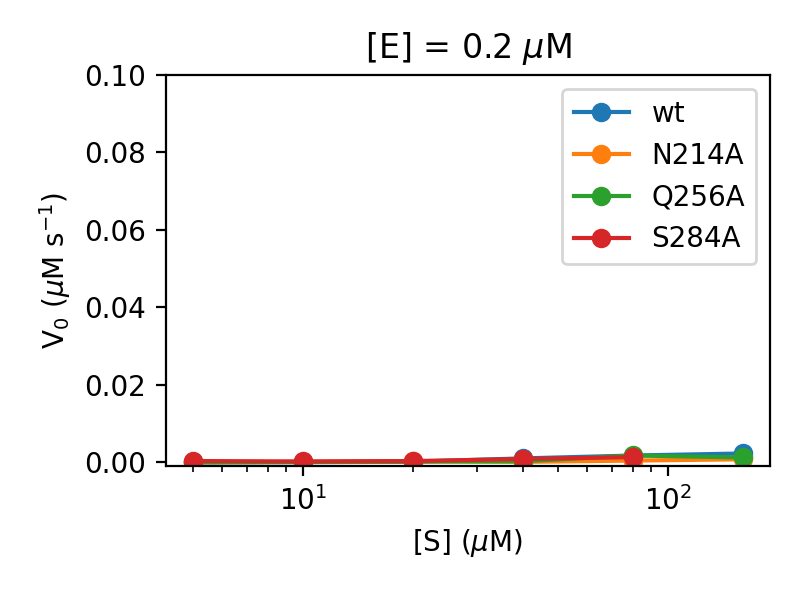

<IPython.core.display.Javascript object>


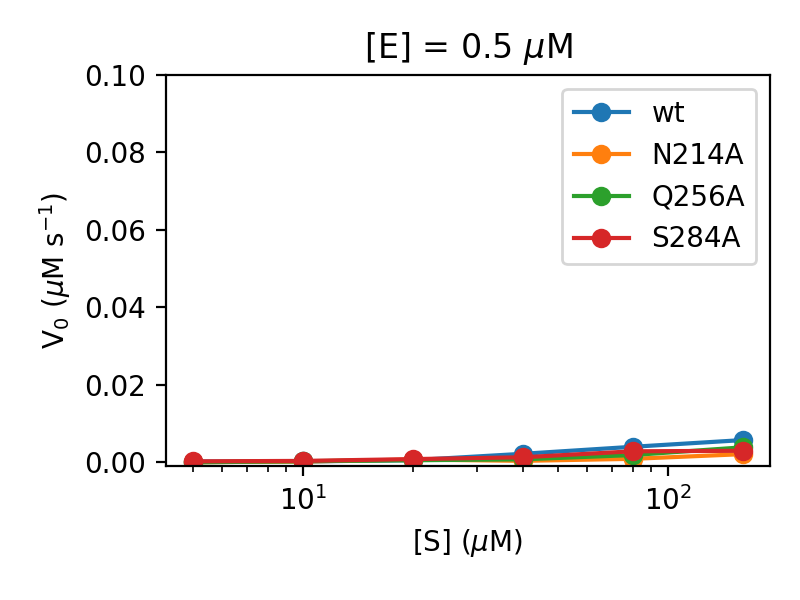

<IPython.core.display.Javascript object>


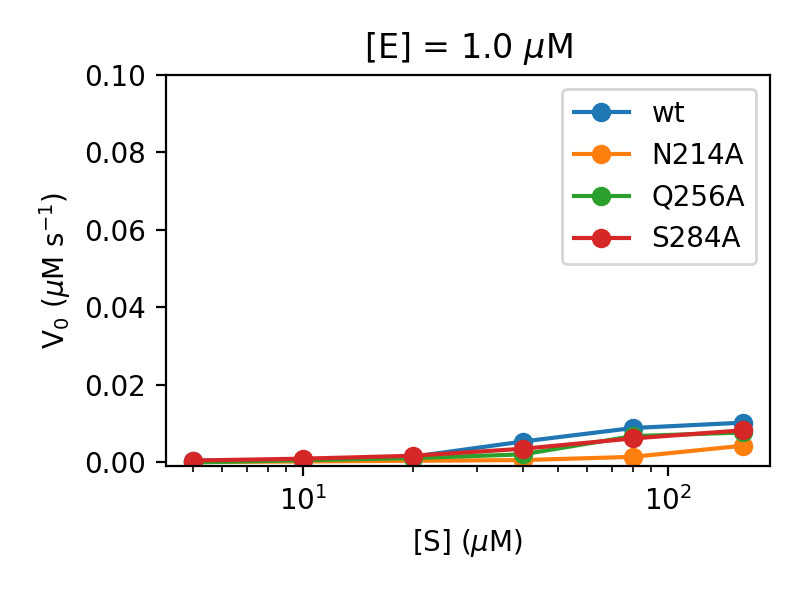

<IPython.core.display.Javascript object>


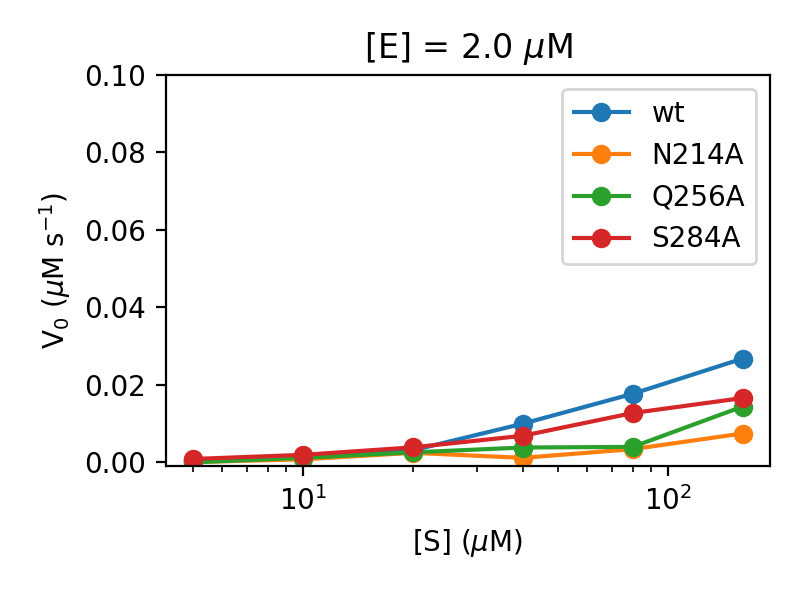

<IPython.core.display.Javascript object>


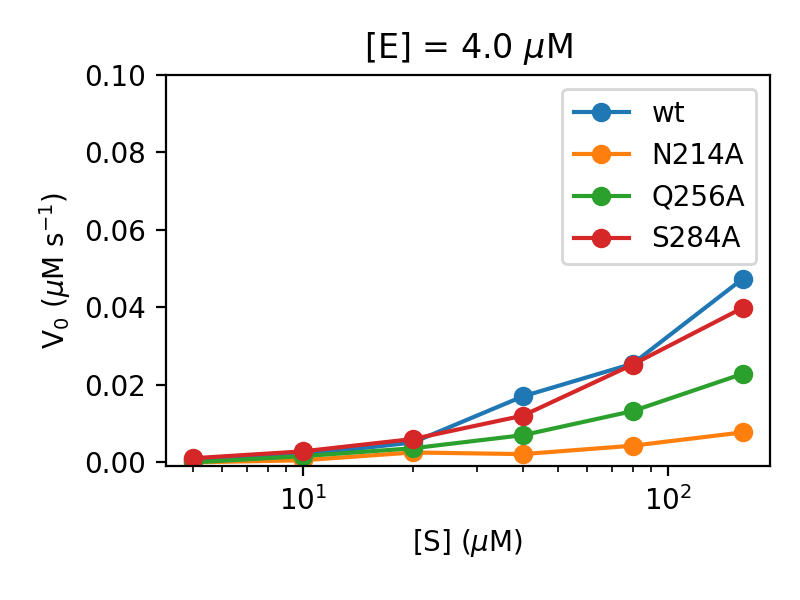

<IPython.core.display.Javascript object>


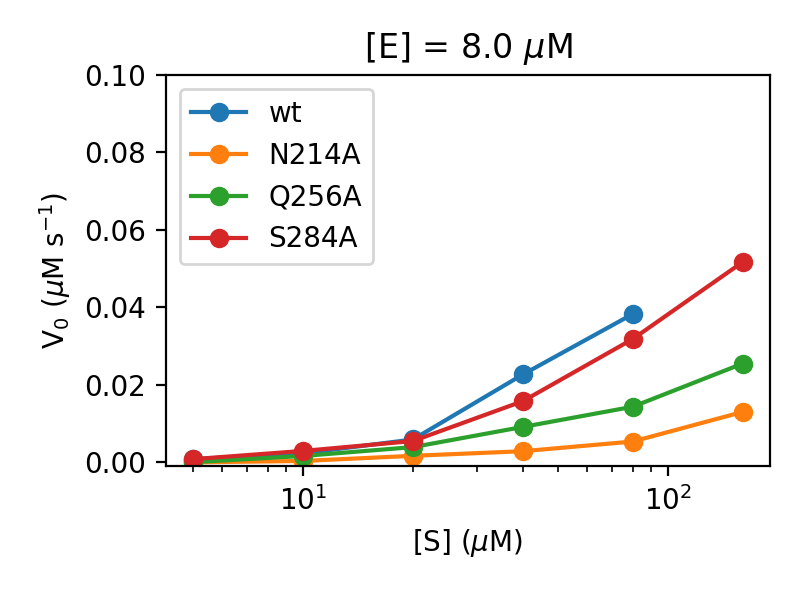

<IPython.core.display.Javascript object>


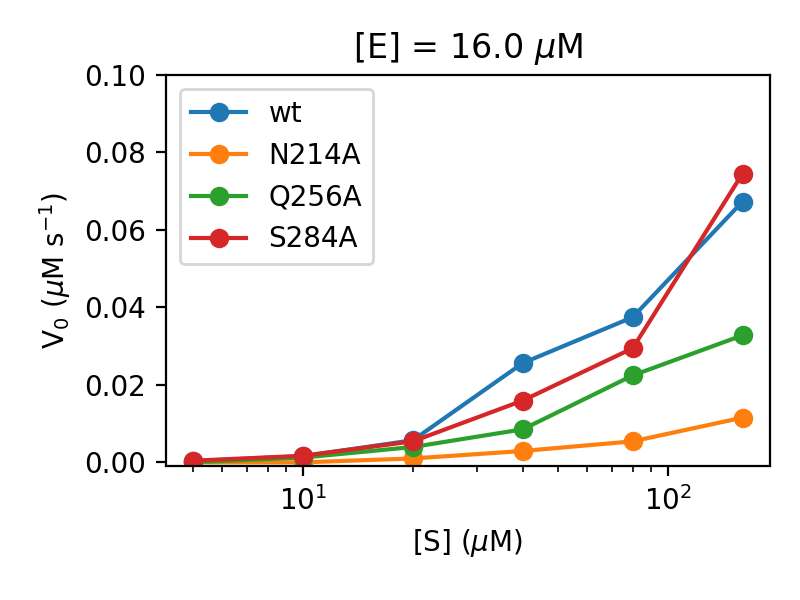

In [16]:
E_conc = 80.0

for E_conc in [5.0, 10.0, 20.0, 40.0, 80.0, 160.0, 320.0]:

    plt.figure(figsize=(4,3))
    plt.title('[E] = %.1f $\mu$M' % (E_conc/20.0,))

    for im, m in enumerate(mutants):

        ks = ks_s[im]

        for j,s in enumerate([E_conc]):
            _, p0s, v0s, v0errs = ks.get_set_v0s(ps, [s])
            plt.plot(p0s, v0s, '-o')
            plt.ylim([-0.001, 0.1])

    plt.legend(mutants)
    plt.xlabel('[S] ($\mu$M)')
    plt.ylabel('V$_0$ ($\mu$M s$^{-1}$)')
    plt.xscale('log')

    plt.tight_layout()
    plt.savefig('figures/v0_vs_subs_conc_%d.pdf' % (int(E_conc),))
    plt.show()